In [1]:
from pathlib import Path
import random

import torch
import pandas as pd
from PIL import Image
from torchvision.transforms import functional as F
from transformers import AutoModel
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent

IAM_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "iam_metadata.csv"
FAIL_META_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "emuru_failures_metadata.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IAM_META_PATH:", IAM_META_PATH)
print("FAIL_META_PATH:", FAIL_META_PATH)


/home/woody/iwi5/iwi5384h/software/private/conda/envs/emuru/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
IAM_META_PATH: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/iam_metadata.csv
FAIL_META_PATH: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/emuru_failures_metadata.csv


In [2]:
iam_df = pd.read_csv(IAM_META_PATH)
fail_df = pd.read_csv(FAIL_META_PATH)

print("IAM rows:", len(iam_df))
print("Failure rows:", len(fail_df))

print("\niam_df columns:", list(iam_df.columns))
print("fail_df columns:", list(fail_df.columns))

def find_column(df: pd.DataFrame, candidates, label: str, required: bool = True):
    """
    Find first existing column from candidates. If required and none found, raise.
    """
    for c in candidates:
        if c in df.columns:
            print(f"{label}: using column '{c}'")
            return c
    if required:
        raise KeyError(
            f"{label}: none of {candidates} found. "
            f"Available columns: {list(df.columns)}"
        )
    else:
        print(f"{label}: no column found from {candidates}, using None")
        return None

# Path columns
IAM_PATH_COL   = find_column(iam_df,  ["iam_filepath", "filepath", "rel_path", "path", "img_path", "image_path"], "IAM path")
FAIL_PATH_COL  = find_column(fail_df, ["iam_filepath", "filepath", "rel_path", "path", "img_path", "image_path"], "FAIL path")

# Text & chunk info
FAIL_TEXT_COL      = find_column(fail_df, ["iam_text", "full_text", "text", "sentence"], "FAIL text")
CHUNK_TEXT_COL     = find_column(fail_df, ["chunk_text", "word_text", "gen_text"], "Chunk text")
CHUNK_INDEX_COL    = find_column(fail_df, ["chunk_index", "word_index", "chunk_id"], "Chunk index")

# Optional columns
ERROR_MESSAGE_COL  = find_column(fail_df, ["error_message"], "Error message", required=False)

# Define tile_fail_df (like your old mask)
if ERROR_MESSAGE_COL is not None:
    mask_tile = fail_df[ERROR_MESSAGE_COL].astype(str).str.contains(
        "tile cannot extend outside image", case=False, na=False
    )
    tile_fail_df = fail_df[mask_tile].copy()
else:
    # Fallback: just use all failures
    tile_fail_df = fail_df.copy()

print("\nFailures with 'tile cannot extend outside image':", len(tile_fail_df))
tile_fail_df.head()


IAM rows: 10373
Failure rows: 589

iam_df columns: ['filepath', 'source', 'label', 'text', 'idx', 'hf_split']
fail_df columns: ['iam_index', 'iam_filepath', 'iam_text', 'stage', 'chunk_index', 'chunk_text', 'error_type', 'error_message']
IAM path: using column 'filepath'
FAIL path: using column 'iam_filepath'
FAIL text: using column 'iam_text'
Chunk text: using column 'chunk_text'
Chunk index: using column 'chunk_index'
Error message: using column 'error_message'

Failures with 'tile cannot extend outside image': 589


,iam_index,iam_filepath,iam_text,stage,chunk_index,chunk_text,error_type,error_message
0,3,data/raw/iam/iam_00003.png,M Ps tomorrow. Mr. Michael Foot has,word_save,0,M Ps,SystemError,tile cannot extend outside image
1,6,data/raw/iam/iam_00006.png,A MOVE to stop Mr. Gaitskell from,word_save,1,to stop,SystemError,tile cannot extend outside image
2,82,data/raw/iam/iam_00082.png,meet in London today to discuss a common,word_save,0,meet in,SystemError,tile cannot extend outside image
3,84,data/raw/iam/iam_00084.png,"Colonial Secretary , Mr. Iain Macleod ,",word_save,2,Iain Macleod,SystemError,tile cannot extend outside image
4,108,data/raw/iam/iam_00108.png,"do if the British demonstrations . """,word_save,1,the British,SystemError,tile cannot extend outside image


In [3]:
import numpy as np
from PIL import ImageOps

def inspect_and_preview_generated(pil_img, label="generated", target_w=800):
    """
    Inspect basic stats of the generated PIL image and show:
    - normal preview
    - autocontrast preview
    - cropped-to-content preview (if any non-white pixels)
    """
    print(f"\n[{label}] size: {pil_img.size}, mode: {pil_img.mode}")

    # Convert to grayscale array for stats/content detection
    arr = np.array(pil_img.convert("L"))
    print(f"[{label}] pixel stats -> min: {arr.min()}, mean: {arr.mean():.2f}, max: {arr.max()}")

    def resize_keep_aspect(img, target_w=target_w):
        w, h = img.size
        if w == 0:
            return img
        new_h = int(h * (target_w / w))
        return img.resize((target_w, new_h))

    # 1) Normal preview
    print(f"\n[{label}] normal preview:")
    display(resize_keep_aspect(pil_img))

    # 2) Autocontrast preview (helps if it's very faint)
    auto = ImageOps.autocontrast(pil_img.convert("L"))
    print(f"\n[{label}] autocontrast preview:")
    display(resize_keep_aspect(auto.convert("RGB")))

    # 3) Crop to content (anything darker than almost-white)
    mask = arr < 250  # tweak threshold if needed
    if mask.any():
        ys, xs = np.where(mask)
        x0, x1 = xs.min(), xs.max() + 1
        y0, y1 = ys.min(), ys.max() + 1
        cropped = pil_img.crop((x0, y0, x1, y1))
        print(f"\n[{label}] cropped-to-content bbox: {(x0, y0, x1, y1)}")
        display(resize_keep_aspect(cropped))
    else:
        print(f"\n[{label}] no pixels darker than threshold → truly blank (all ~white).")


In [4]:
def pick_device(device_arg: str = "auto") -> torch.device:
    device_arg = device_arg.lower()

    if device_arg == "cpu":
        return torch.device("cpu")
    if device_arg == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device_arg == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")

    # auto
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def load_style_image(img_path: Path) -> torch.Tensor:
    """
    Load an IAM image as Emuru style_img tensor:
    - RGB
    - resized to height 64
    - tensor (C, H, W)
    - normalized to [-1, 1]
    """
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img.width * 64 // img.height, 64))
    t = F.to_tensor(img)
    t = F.normalize(t, [0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    return t  # (C, H, W)


device = pick_device("auto")
print("Using device:", device)


Using device: cpu


In [5]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

model = AutoModel.from_pretrained(
    "blowing-up-groundhogs/emuru",
    trust_remote_code=True,
    local_files_only=True,
).to(device)
model.eval()

print("Emuru model loaded.")


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/home/woody/iwi5/iwi5384h/software/private/conda/envs/emuru/lib/python3.12/site-packages/torch/nn/modules/module.py:2446: UserWarning: for encoder.conv_in.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/woody/iwi5/iwi5384h/software/private/conda/envs/emuru/lib/python3.12/site-packages/torch/nn/modules/module.py:2446: UserWarning: for encoder.conv_in.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, 

Emuru model loaded.


In [6]:
def debug_failed_chunk_random_style(row: pd.Series):
    """
    For ONE failure row:
    - Show the original failed IAM line (from fail_df).
    - Pick a RANDOM IAM line as style_img.
    - Keep the same chunk_text.
    - Generate with Emuru and show the new word image.

    No files are written.
    """
    # --- Original failure info (from fail_df row) ---
    iam_rel = Path(row[FAIL_PATH_COL])
    iam_abs = PROJECT_ROOT / iam_rel

    full_text   = str(row[FAIL_TEXT_COL])
    chunk_index = row[CHUNK_INDEX_COL]
    chunk_text  = str(row[CHUNK_TEXT_COL])

    error_msg = str(row[ERROR_MESSAGE_COL]) if ERROR_MESSAGE_COL is not None and ERROR_MESSAGE_COL in row else ""

    print("=" * 120)
    print(f"Failed IAM filepath: {iam_rel}")
    print(f"Chunk index:         {chunk_index}")
    print(f"Chunk text:          {repr(chunk_text)}")
    print(f"Prev error msg:      {error_msg}")
    print("-" * 120)

    # --- Pick a random IAM line as style image ---
    donor_row = iam_df.sample(1).iloc[0]
    donor_rel = Path(donor_row[IAM_PATH_COL])
    donor_abs = PROJECT_ROOT / donor_rel

    print("Using RANDOM donor style:")
    print(f"  donor filepath: {donor_rel}")
    print("-" * 120)

    # Inputs to Emuru
    style_text = full_text[:80]  # same sentence context
    style_img  = load_style_image(donor_abs).to(device)

    with torch.no_grad():
        emuru_word_img = model.generate(
            style_text=style_text,
            gen_text=chunk_text,
            style_img=style_img,
            max_new_tokens=256,
        )

    emuru_word_img.load()
    pil_img = emuru_word_img.convert("RGB")

    inspect_and_preview_generated(pil_img, label="Emuru random-style")

    # Helper for resizing in notebook
    def resize_keep_aspect(img, target_w=800):
        w, h = img.size
        if w == 0:
            return img
        new_h = int(h * (target_w / w))
        return img.resize((target_w, new_h))

    print("\nOriginal (failed) IAM line image:")
    failed_iam_img = Image.open(iam_abs).convert("RGB")
    display(resize_keep_aspect(failed_iam_img, target_w=800))

    print("Donor style IAM line image:")
    donor_iam_img = Image.open(donor_abs).convert("RGB")
    display(resize_keep_aspect(donor_iam_img, target_w=800))

    print("Generated Emuru word image with RANDOM donor style:")
    display(resize_keep_aspect(pil_img, target_w=800))

    return pil_img


Failed IAM filepath: data/raw/iam/iam_00003.png
Chunk index:         0
Chunk text:          'M Ps'
Prev error msg:      tile cannot extend outside image
------------------------------------------------------------------------------------------------------------------------
Using RANDOM donor style:
  donor filepath: data/raw/iam/iam_09245.png
------------------------------------------------------------------------------------------------------------------------


[W1129 09:53:33.623365828 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1129 09:59:23.098571913 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W1129 09:59:23.098777388 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.



[Emuru random-style] size: (2037, 64), mode: RGB
[Emuru random-style] pixel stats -> min: 169, mean: 252.85, max: 255

[Emuru random-style] normal preview:



[Emuru random-style] autocontrast preview:



[Emuru random-style] cropped-to-content bbox: (np.int64(0), np.int64(22), np.int64(2036), np.int64(38))



Original (failed) IAM line image:


Donor style IAM line image:


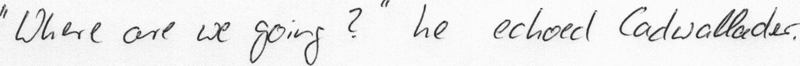

Generated Emuru word image with RANDOM donor style:


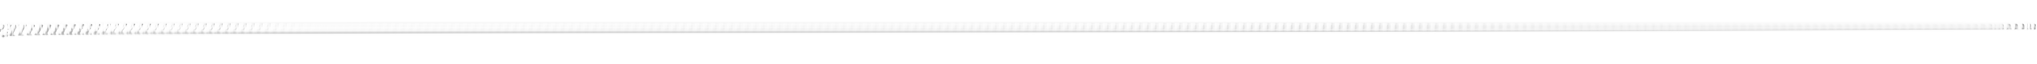

In [7]:
# Example: first tile failure if available; otherwise first failure
if len(tile_fail_df) > 0:
    row = tile_fail_df.iloc[0]
else:
    row = fail_df.iloc[0]

result_img = debug_failed_chunk_random_style(row)
result_img
